In [11]:
!pip install -U albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 30.0 MB/s  0:00:02 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.6/583.6 kB 25.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [albumentations] 3/5 [albucore]thon-headless]


In [22]:
!pip install transformers
!pip cache purge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 14.9 MB/s  0:00:00a 0:00:016m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 28.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 23.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 33.1 MB/s  0:00:00
Using cached filelock-3.29.0-py3-none-any.whl (39 kB)
Using cached fsspec-2026.3.0-py3-none-any.whl (202 kB)
Using cached regex-2026.4.4-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (801 kB)
Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (507 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [transformers]0m 7/8 [transformers]
Files removed: 62 (217.6 MB)


In [31]:
!pip install torch --index-url https://download.pytorch.org/whl/cpu
!pip install transformers

Looking in indexes: https://download.pytorch.org/whl/cpu


In [29]:
!pip install "transformers[tf]"
!pip cache purge

Files removed: 18 (199.3 MB)


In [2]:
import pandas as pd
import os
import cv2
import tensorflow as tf
from tensorflow import keras
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
import glob
import warnings
import csv
from collections import OrderedDict
from sklearn.model_selection import train_test_split

2026-05-17 14:58:18.020327: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 14:58:18.407263: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-17 14:58:19.775207: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
BASE_INPUT_PATH = "/home/bigbro/Dataset_CBIS"
CSV_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "csv")
IMAGE_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "jpeg")
BASE_OUTPUT_PATH = "/home/bigbro/"

In [4]:
IMAGE_SIZE = 256
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
LEARNING_RATE = 1e-4
NUM_EPOCHS = 100
RANDOM_SEED = 42
tf.keras.utils.set_random_seed(42)

In [ ]:
def find_image_in_folder(folder_path):
    """
    Trouve la première image .jpg ou .png dans le dossier ET ses sous-dossiers.
    """
    if not folder_path or not os.path.isdir(folder_path):
        return None
        
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png')):
                return os.path.join(root, file)
                
    return None

def compute_all_bounding_boxes(mask_path, min_area=100):
    """
    Returns a list of bounding boxes [[x_min, y_min, width, height],...]
    Returns None if mask doesn't exist or is invalid
    """
    if not os.path.exists(mask_path):
        return None

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    _, thresh = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w * h < min_area:
            continue
        boxes.append([x, y, w, h])

    return boxes if boxes else None

def build_metadata_lookup(dicom_info_path, jpeg_base_dir, *args):
    print(f"Building metadata lookup from: {dicom_info_path}")
    master_map = {}
    
    try:
        dicom_info = pd.read_csv(dicom_info_path, dtype=str)
    except FileNotFoundError:
        print(f"Error: Metadata file not found at {dicom_info_path}")
        return master_map

    valid_descriptions = {arg for arg in args}
    filtered_df = dicom_info[dicom_info['SeriesDescription'].isin(valid_descriptions)]

    for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df), desc="Building lookup map"):
        series_desc = row['SeriesDescription'] 
        patient_id_composite = row['PatientID'] 
        
        full_path = None
        
        if 'image_path' in row and pd.notna(row['image_path']):
            rel_path = row['image_path']
            if 'jpeg' in rel_path:
                clean_rel_path = rel_path.split('jpeg')[-1].strip("/\\")
                tmp_path = os.path.join(jpeg_base_dir, clean_rel_path)
            else:
                tmp_path = os.path.join(jpeg_base_dir, rel_path)

            if os.path.exists(tmp_path):
                full_path = tmp_path

        if not full_path:
            series_uid = row['SeriesInstanceUID']
            folder_path = os.path.join(jpeg_base_dir, series_uid)
            full_path = find_image_in_folder(folder_path)
            
        if not full_path or not os.path.exists(full_path): 
            continue

        if patient_id_composite not in master_map:
            master_map[patient_id_composite] = {}
            
        master_map[patient_id_composite][series_desc] = full_path
            
    print(f"Metadata lookup map built. Found {len(master_map)} unique composite keys.")
    return master_map


In [ ]:
def BuildMasterDataset(MASTER_LIST_PATH="/home/bigbro/master_dataset.csv", 
                       argument1="cropped images", 
                       argument2="ROI mask images"):
    """
    Build master dataset. If ROI mask is missing:
    - For BENIGN cases: sets mask path to 'n/a' and bbox to 'n/a'
    - For MALIGNANT cases: skips the image entirely
    """
    BASE_INPUT_PATH = "/home/bigbro/Dataset_CBIS"
    IMAGE_FOLDER_PATH = os.path.join(BASE_INPUT_PATH, "jpeg")
    DICOM_INFO_PATH = os.path.join(BASE_INPUT_PATH, "csv/dicom_info.csv")
    
    INPUT_CSVS = [
        os.path.join(BASE_INPUT_PATH, "csv/mass_case_description_train_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/mass_case_description_test_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/calc_case_description_train_set.csv"),
        os.path.join(BASE_INPUT_PATH, "csv/calc_case_description_test_set.csv")
    ]

    # Build the authoritative map
    master_map = build_metadata_lookup(DICOM_INFO_PATH, IMAGE_FOLDER_PATH, argument1, argument2)
    
    if not master_map:
        return

    found_pairs_count = 0
    missing_mask_count = 0
    skipped_malignant_count = 0
    
    with open(MASTER_LIST_PATH, 'w', newline='') as outfile:
        csv_writer = csv.writer(outfile)
        csv_writer.writerow([
            'cropped_image_path', 'roi_mask_path',
            'x_min', 'y_min', 'width', 'height',
            'pathology', 'assessment', 'patient_id', 'series_type', 'mask_status'
        ])

        for filepath in INPUT_CSVS:
            filename = os.path.basename(filepath)
            if not filepath or not os.path.exists(filepath):
                continue
            
            if "mass" in filename.lower():
                type_prefix = "Mass"
            elif "calc" in filename.lower():
                type_prefix = "Calc"
            else:
                continue
                
            if "train" in filename.lower():
                split_prefix = "Training"
            elif "test" in filename.lower():
                split_prefix = "Test"
            else:
                continue
                
            full_prefix = f"{type_prefix}-{split_prefix}"

            with open(filepath, "r") as infile:
                csv_reader = csv.reader(infile)
                header = next(csv_reader)
                
                pathology_idx = header.index('pathology')
                assessment_idx = header.index('assessment')
                patient_id_idx = header.index('patient_id')
                breast_idx = header.index('left or right breast')
                view_idx = header.index('image view')
                abnormality_id_idx = header.index('abnormality id')

                for row in tqdm(csv_reader, desc=f"Processing {filename}"):
                    if not any(row):
                        continue
                    
                    pathology = row[pathology_idx]
                    assessment = row[assessment_idx]
                    patient_id = row[patient_id_idx]
                    side = row[breast_idx]
                    view = row[view_idx]
                    abn_id = row[abnormality_id_idx]
                    
                    try:
                        abn_id_clean = str(int(float(abn_id)))
                    except ValueError:
                        abn_id_clean = str(abn_id).strip()

                    composite_key = f"{full_prefix}_{patient_id}_{side}_{view}_{abn_id_clean}"
                    
                    study_data = master_map.get(composite_key)
                    if not study_data:
                        continue
                    
                    full_crop_path = study_data.get('cropped images')
                    full_mask_path = study_data.get('ROI mask images')
                    
                    # Check if cropped image exists
                    if not full_crop_path:
                        continue
                    
                    mask_status = 'valid'
                    
                    # Handle missing mask based on pathology
                    if not full_mask_path:
                        pathology_upper = str(pathology).upper()
                        is_benign = 'BENIGN' in pathology_upper and 'MALIGNANT' not in pathology_upper
                        
                        if is_benign:
                            full_mask_path = 'n/a'
                            mask_status = 'n/a'
                            missing_mask_count += 1
                            
                            csv_writer.writerow([
                                full_crop_path,
                                'n/a',  # roi_mask_path
                                'n/a', 'n/a', 'n/a', 'n/a',  
                                pathology,
                                assessment,
                                patient_id,
                                full_prefix,
                                'n/a'  # mask_status
                            ])
                            found_pairs_count += 1
                        else:
                            skipped_malignant_count += 1
                        continue
                    
                    if full_crop_path == full_mask_path and mask_status == 'valid':
                        continue
                    
                    boxes = compute_all_bounding_boxes(full_mask_path, min_area=100)
                    
                    if boxes is None:
                        csv_writer.writerow([
                            full_crop_path,
                            full_mask_path,
                            'n/a', 'n/a', 'n/a', 'n/a',
                            pathology,
                            assessment,
                            patient_id,
                            full_prefix,
                            mask_status
                        ])
                        found_pairs_count += 1
                    else:
                        for (x_min, y_min, width, height) in boxes:
                            csv_writer.writerow([
                                full_crop_path,
                                full_mask_path,
                                x_min, y_min, width, height,
                                pathology,
                                assessment,
                                patient_id,
                                full_prefix,
                                mask_status
                            ])
                            found_pairs_count += 1

    print(f"\n{'='*60}")
    print(f"DATASET BUILD SUMMARY")
    print(f"{'='*60}")
    print(f"Master list saved to: {MASTER_LIST_PATH}")
    print(f"Valid pairs found: {found_pairs_count}")
    print(f"Benign cases without masks (n/a): {missing_mask_count}")
    print(f"Malignant cases skipped (no mask): {skipped_malignant_count}")
    print(f"{'='*60}")

BuildMasterDataset()

Building metadata lookup from: /home/bigbro/Dataset_CBIS/csv/dicom_info.csv


Building lookup map: 100%|███████████████| 6814/6814 [00:00<00:00, 18461.21it/s]


Metadata lookup map built. Found 3539 unique composite keys.


Processing mass_case_description_train_set.csv: 1318it [00:20, 64.82it/s]
Processing mass_case_description_test_set.csv: 378it [00:05, 64.00it/s]
Processing calc_case_description_train_set.csv: 1546it [00:23, 66.09it/s]
Processing calc_case_description_test_set.csv: 326it [00:00, 2128.52it/s]


DATASET BUILD SUMMARY
Master list saved to: /home/bigbro/master_dataset.csv
Valid pairs found: 3416
Benign cases without masks (n/a): 192
Malignant cases skipped (no mask): 126


In [ ]:
MASTER_LIST_PATH = "/home/bigbro/master_dataset.csv"

df_master = pd.read_csv(MASTER_LIST_PATH, keep_default_na=False)

unique_patients = df_master["patient_id"].unique()
train_patients, val_patients = train_test_split(
    unique_patients,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_SEED
)

print(f"Splitting {len(unique_patients)} unique patients: {len(train_patients)} for training, {len(val_patients)} for validation.")

Splitting 1508 unique patients: 1206 for training, 302 for validation.


In [8]:
train_df = df_master[df_master['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df = df_master[df_master['patient_id'].isin(val_patients)].reset_index(drop=True)
train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),
    A.GridDistortion(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
   
])

val_transforms = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    
])

/home/bigbro/miniconda3/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_46463/819158041.py:9: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.3),


In [ ]:
class MammographyDataSequence(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, transforms=None, image_size=224):
        self.dataframe = dataframe
        self.batch_size = batch_size
        self.transforms = transforms
        self.image_size = image_size

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_df = self.dataframe.iloc[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        images = []
        masks = []
        labels = []

        for _, row in batch_df.iterrows():
            img, msk, lbl = self._load_data(row)
            images.append(img)
            masks.append(msk)
            labels.append(lbl)

        return np.array(images), np.array(masks)

    def _load_data(self, row):
        image_path = row["cropped_image_path"]
        mask_path = row["roi_mask_path"]
        mask_status = row["mask_status"]
        pathology = row["pathology"]
        
        label = 1 if 'MALIGNANT' in str(pathology).upper() else 0
        
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if image is None:
            image = np.zeros((self.image_size, self.image_size, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (self.image_size, self.image_size))

        h, w, _ = image.shape 

        if mask_status == 'n/a' or mask_path == 'n/a' or str(row['x_min']) == 'n/a':
            mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
        else:
            full_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if full_mask is None:
                mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
            else:
                x_min = max(0, int(float(row['x_min'])))
                y_min = max(0, int(float(row['y_min'])))
                x_max = min(full_mask.shape[1], x_min + int(float(row['width'])))
                y_max = min(full_mask.shape[0], y_min + int(float(row['height'])))
                
                mask_crop = full_mask[y_min:y_max, x_min:x_max]
                
                if mask_crop.size == 0:
                    mask = np.zeros((self.image_size, self.image_size), dtype=np.uint8)
                else:
                    mask = cv2.resize(mask_crop, (self.image_size, self.image_size))
        
        _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        mask = mask.astype(np.float32) / 255.0

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        if mask.ndim == 2:
            mask = np.expand_dims(mask, axis=-1)
            
        return image, mask, label

In [ ]:

train_df_unet = train_df[train_df['mask_status'] != 'n/a'].reset_index(drop=True)
val_df_unet = val_df[val_df['mask_status'] != 'n/a'].reset_index(drop=True)
train_generator = MammographyDataSequence(
    train_df_unet, 
    batch_size=BATCH_SIZE, 
    transforms=train_transforms,
    image_size=IMAGE_SIZE
)

val_generator = MammographyDataSequence(
    val_df_unet, 
    batch_size=BATCH_SIZE, 
    transforms=val_transforms,
    image_size=IMAGE_SIZE
)

print(f"U-Net Training samples: {len(train_df)}")
print(f"U-Net Validation samples: {len(val_df)}")
print(f"Number of training batches: {len(train_generator)}")
print(f"Number of validation batches: {len(val_generator)}")

U-Net Training samples: 2731
U-Net Validation samples: 685
Number of training batches: 162
Number of validation batches: 40


In [10]:
#####################################
####### METRICS ####################
###################################

In [11]:
from tensorflow.keras import backend as K
def dice_coef(y_true,y_pred,smooth=1e-6):
    # we flat out tensor
    y_true_f=K.flatten(K.cast(y_true,'float32'))
    y_pred_f=K.flatten(y_pred)

    #calculate intersection
    intersection=K.sum(y_true_f*y_pred_f)
    return (2.*intersection+smooth) / (K.sum(y_true_f)+K.sum(y_pred_f)+smooth)
def dice_loss(y_true,y_pred):
    return 1-dice_coef(y_true,y_pred)

In [12]:
def specificity(y_true, y_pred):
    y_true = K.cast(y_true, 'float32')
    true_negatives = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = K.sum(K.round(K.clip(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def f1_score(y_true, y_pred):
    p = keras.metrics.Precision()(y_true, y_pred)
    r = keras.metrics.Recall()(y_true, y_pred)
    return 2 * ((p * r) / (p + r + K.epsilon()))

In [ ]:
def channel_attention_module(x, ratio=8):
    channels=x.shape[-1]
    shared_layer_one=keras.layers.Dense(channels // ratio, activation="relu", use_bias=False)
    shared_layer_two=keras.layers.Dense(channels, use_bias=False)

    # avgpool 
    avg_pool=keras.layers.GlobalAveragePooling2D()(x)
    avg_pool=keras.layers.Reshape((1,1,channels))(avg_pool)
    avg_out=shared_layer_two(shared_layer_one(avg_pool))

    #maxpool
    max_pool=keras.layers.GlobalMaxPooling2D()(x)
    max_pool=keras.layers.Reshape((1,1,channels))(max_pool)
    max_out=shared_layer_two(shared_layer_one(max_pool))

    cbam_feature=keras.layers.Add()([avg_out,max_out])
    cbam_feature=keras.layers.Activation('sigmoid')(cbam_feature)

    return keras.layers.multiply([x,cbam_feature])

In [14]:
from keras import ops
def spatial_attention_module(x):
    #
    avg_pool = ops.mean(x,axis=-1,keepdims=True)
    max_pool= ops.max(x,axis=-1,keepdims=True)

    #concatenation
    concat=keras.layers.Concatenate(axis=-1)([avg_pool, max_pool])

    #7x7 filter and sigmoid
    cbam_feature=keras.layers.Conv2D(
        filters=1, kernel_size=7, strides=1,
        padding="same", activation="sigmoid", use_bias=False
    )(concat)

    #muliply and return
    return keras.layers.multiply([x,cbam_feature])

In [15]:
def cbam_block(x,ratio=8):
    x=channel_attention_module(x,ratio)
    x=spatial_attention_module(x)
    return x

In [16]:
def hybrid_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    return (0.95 * dice_loss(y_true, y_pred)) + (0.05 * tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred)))

In [17]:
def log_cosh_dice_loss(y_true, y_pred):
    x = dice_loss(y_true, y_pred)
    return tf.math.log(tf.math.cosh(x))

In [18]:
def VGG19_unet_trans(img_size):
    inputs = keras.Input(shape=img_size + (3,))

    base_model = keras.applications.VGG19(
        include_top=False,
        weights="imagenet",
        input_shape=(256,256,3),
        input_tensor=inputs
    )
    base_model.trainable = False

    s1 = base_model.get_layer("block1_conv2").output
    s2 = base_model.get_layer("block2_conv2").output
    s3 = base_model.get_layer("block3_conv2").output
    s4 = base_model.get_layer("block4_conv2").output
    b1 = base_model.get_layer("block5_conv4").output
    b1=cbam_block(b1)

    u6 = keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding="same")(b1)
    u6 = keras.layers.concatenate([u6, s4])
    c6 = keras.layers.Conv2D(128, 3, activation="relu", kernel_initializer="he_normal", padding="same")(u6)
    c6 = keras.layers.Dropout(0.5)(c6)
    c6 = keras.layers.Conv2D(128, 3, activation="relu", kernel_initializer="he_normal", padding="same")(c6)

    
    u7 = keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding="same")(c6)
    u7 = keras.layers.concatenate([u7, s3])
    c7 = keras.layers.Conv2D(64, 3, activation="relu", kernel_initializer="he_normal", padding="same")(u7)
    c7 = keras.layers.Dropout(0.4)(c7)
    c7 = keras.layers.Conv2D(64, 3, activation="relu", kernel_initializer="he_normal", padding="same")(c7)

    
    u8 = keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding="same")(c7)
    u8 = keras.layers.concatenate([u8, s2])
    c8 = keras.layers.Conv2D(32, 3, activation="relu", kernel_initializer="he_normal", padding="same")(u8)
    c8 = keras.layers.Dropout(0.3)(c8)
    c8 = keras.layers.Conv2D(32, 3, activation="relu", kernel_initializer="he_normal", padding="same")(c8)

    
    u9 = keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding="same")(c8)
    u9 = keras.layers.concatenate([u9, s1])
    c9 = keras.layers.Conv2D(16, 3, activation="relu", kernel_initializer="he_normal", padding="same")(u9)
    c9 = keras.layers.Dropout(0.2)(c9)
    c9 = keras.layers.Conv2D(16, 3, activation="relu", kernel_initializer="he_normal", padding="same")(c9)

    outputs=keras.layers.Conv2D(1,(1,1), activation="sigmoid")(c9)
    model=keras.Model(inputs,outputs)
    return model

model=VGG19_unet_trans((256,256))
model.summary()

I0000 00:00:1779026416.104611   46463 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 256, 256,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 128, 128,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 128, 128,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 128, 128,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 64, 64,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 64, 64,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 64, 64,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 64, 64,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 64, 64,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 32, 32,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 32, 32,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 32, 32,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 32, 32,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 32, 32,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 16, 16,    │          0 │ block4_conv4[0][

 Total params: 21,570,947 (82.29 MB)

 Trainable params: 1,546,563 (5.90 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice_loss = 1.0 - dice_coef(y_true, y_pred)
    return bce + dice_loss

In [26]:
custom_dict = {
    'bce_dice_loss': bce_dice_loss,
    'specificity': specificity,
    'dice_coef': dice_coef
}

model= keras.models.load_model("/home/bigbro/Bureau/Projet_PFE_models/DDSM_VGG19_U-NET_FT.keras", custom_objects=custom_dict)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=["accuracy", 
             keras.metrics.Precision(name='precision'), 
             keras.metrics.Recall(name='recall'), 
             specificity, 
             dice_coef]
)

In [27]:
model.evaluate(val_generator)

/home/bigbro/miniconda3/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2026-05-17 15:04:17.960205: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e5adc0062c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-17 15:04:17.960227: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-05-17 15:04:18.008296: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-17 15:04:18.131976: I external/local_xla/xla/stream_executor/cuda

 2/40 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8788 - dice_coef: 0.8694 - loss: 0.4096 - precision: 0.8816 - recall: 0.9334 - specificity: 0.7877 

I0000 00:00:1779026667.567996   47467 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.8692 - dice_coef: 0.8616 - loss: 0.4439 - precision: 0.8717 - recall: 0.9309 - specificity: 0.7603

2026-05-17 15:04:34.732659: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-05-17 15:04:34.999083: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 16 bytes spill stores, 16 bytes spill loads

2026-05-17 15:04:35.066214: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 8 bytes spill stores, 8 bytes spill loads

2026-05-17 15:04:36.719781: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.77GiB with freed_by_count=0. The caller indicates that thi

40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 362ms/step - accuracy: 0.8447 - dice_coef: 0.8486 - loss: 0.5090 - precision: 0.8581 - recall: 0.9148 - specificity: 0.7065


[0.5090397596359253,
 0.844722330570221,
 0.8580539226531982,
 0.9148243069648743,
 0.7064954042434692,
 0.8485891222953796]

In [ ]:
callbacks=[
    keras.callbacks.ModelCheckpoint("DDSM_VGG19_U-NET.keras",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_dice_coef", patience=7, restore_best_weights=True, mode="max"),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coef', 
        mode='max',
        factor=0.5,   
        patience=3,  
        min_lr=1e-6,
        verbose=1)
]
history=model.fit(train_generator, 
                  validation_data=val_generator,
                  epochs=50,
                  callbacks=callbacks)

Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 254ms/step - accuracy: 0.8435 - dice_coef: 0.8418 - loss: 0.5183 - precision: 0.8537 - recall: 0.9088 - specificity: 0.7349 - val_accuracy: 0.8332 - val_dice_coef: 0.8394 - val_loss: 0.5419 - val_precision: 0.8420 - val_recall: 0.9183 - val_specificity: 0.6712 - learning_rate: 1.0000e-04
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 246ms/step - accuracy: 0.8459 - dice_coef: 0.8446 - loss: 0.5061 - precision: 0.8562 - recall: 0.9107 - specificity: 0.7379 - val_accuracy: 0.8358 - val_dice_coef: 0.8299 - val_loss: 0.5340 - val_precision: 0.8754 - val_recall: 0.8744 - val_specificity: 0.7627 - learning_rate: 1.0000e-04
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 37s 228ms/step - accuracy: 0.8469 - dice_coef: 0.8445 - loss: 0.5059 - precision: 0.8573 - recall: 0.9105 - specificity: 0.7403 - val_accuracy: 0.8369 - val_dice_coef: 0.8322 - val_loss: 0.5338 - val_precision: 0.8525 - val_recall: 0.9087 - val_specificity: 0.6997 - learning_rate: 1.0000e-04
E

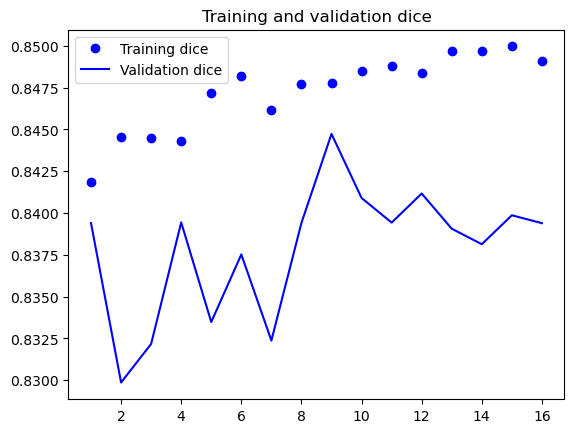

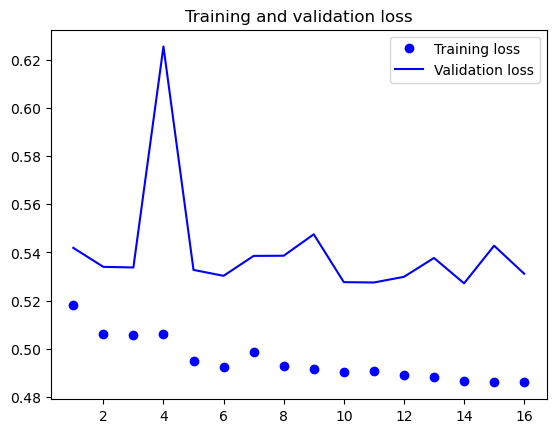

In [82]:
dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(dice) + 1)
plt.plot(epochs, dice, "bo", label="Training dice")
plt.plot(epochs, val_dice, "b", label="Validation dice")
plt.title("Training and validation dice")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


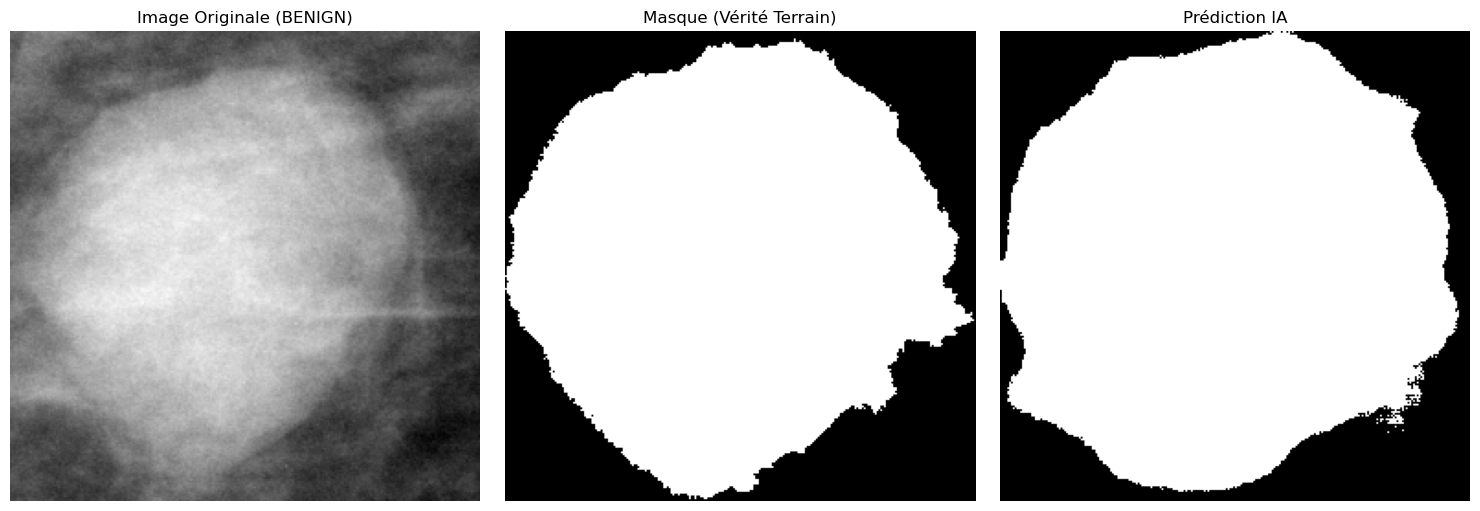

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

idx = 4
IMAGE_SIZE = 256 

img_path_to_test = val_df['cropped_image_path'].iloc[idx]
msk_path_to_test = val_df['roi_mask_path'].iloc[idx]

raw_img = cv2.imread(img_path_to_test)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (IMAGE_SIZE, IMAGE_SIZE))

raw_msk = cv2.imread(msk_path_to_test, cv2.IMREAD_GRAYSCALE)

x_min, y_min = int(float(val_df['x_min'].iloc[idx])), int(float(val_df['y_min'].iloc[idx]))
w, h = int(float(val_df['width'].iloc[idx])), int(float(val_df['height'].iloc[idx]))
raw_msk = raw_msk[y_min:y_min+h, x_min:x_min+w]

raw_msk_resized = cv2.resize(raw_msk, (IMAGE_SIZE, IMAGE_SIZE))
_, raw_msk_resized = cv2.threshold(raw_msk_resized, 127, 255, cv2.THRESH_BINARY)

transformed = val_transforms(image=raw_img)
img_for_model = transformed["image"]

preds = model.predict(np.expand_dims(img_for_model, 0))

if isinstance(preds, list):
    pred_final = preds[1][0] 
else:
    pred_final = preds[0]

pred_mask = (pred_final > 0.5).astype("uint8")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(raw_img)
plt.title(f"Original Image ({val_df['pathology'].iloc[idx]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(raw_msk_resized, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask.squeeze() * 255, cmap="gray")
plt.title("Prediction (AI)")
plt.axis("off")

plt.tight_layout()
plt.show()

Chargement du dataset...
✅ 3224 cas avec masques trouvés. Tirage de 3 exemples au hasard...


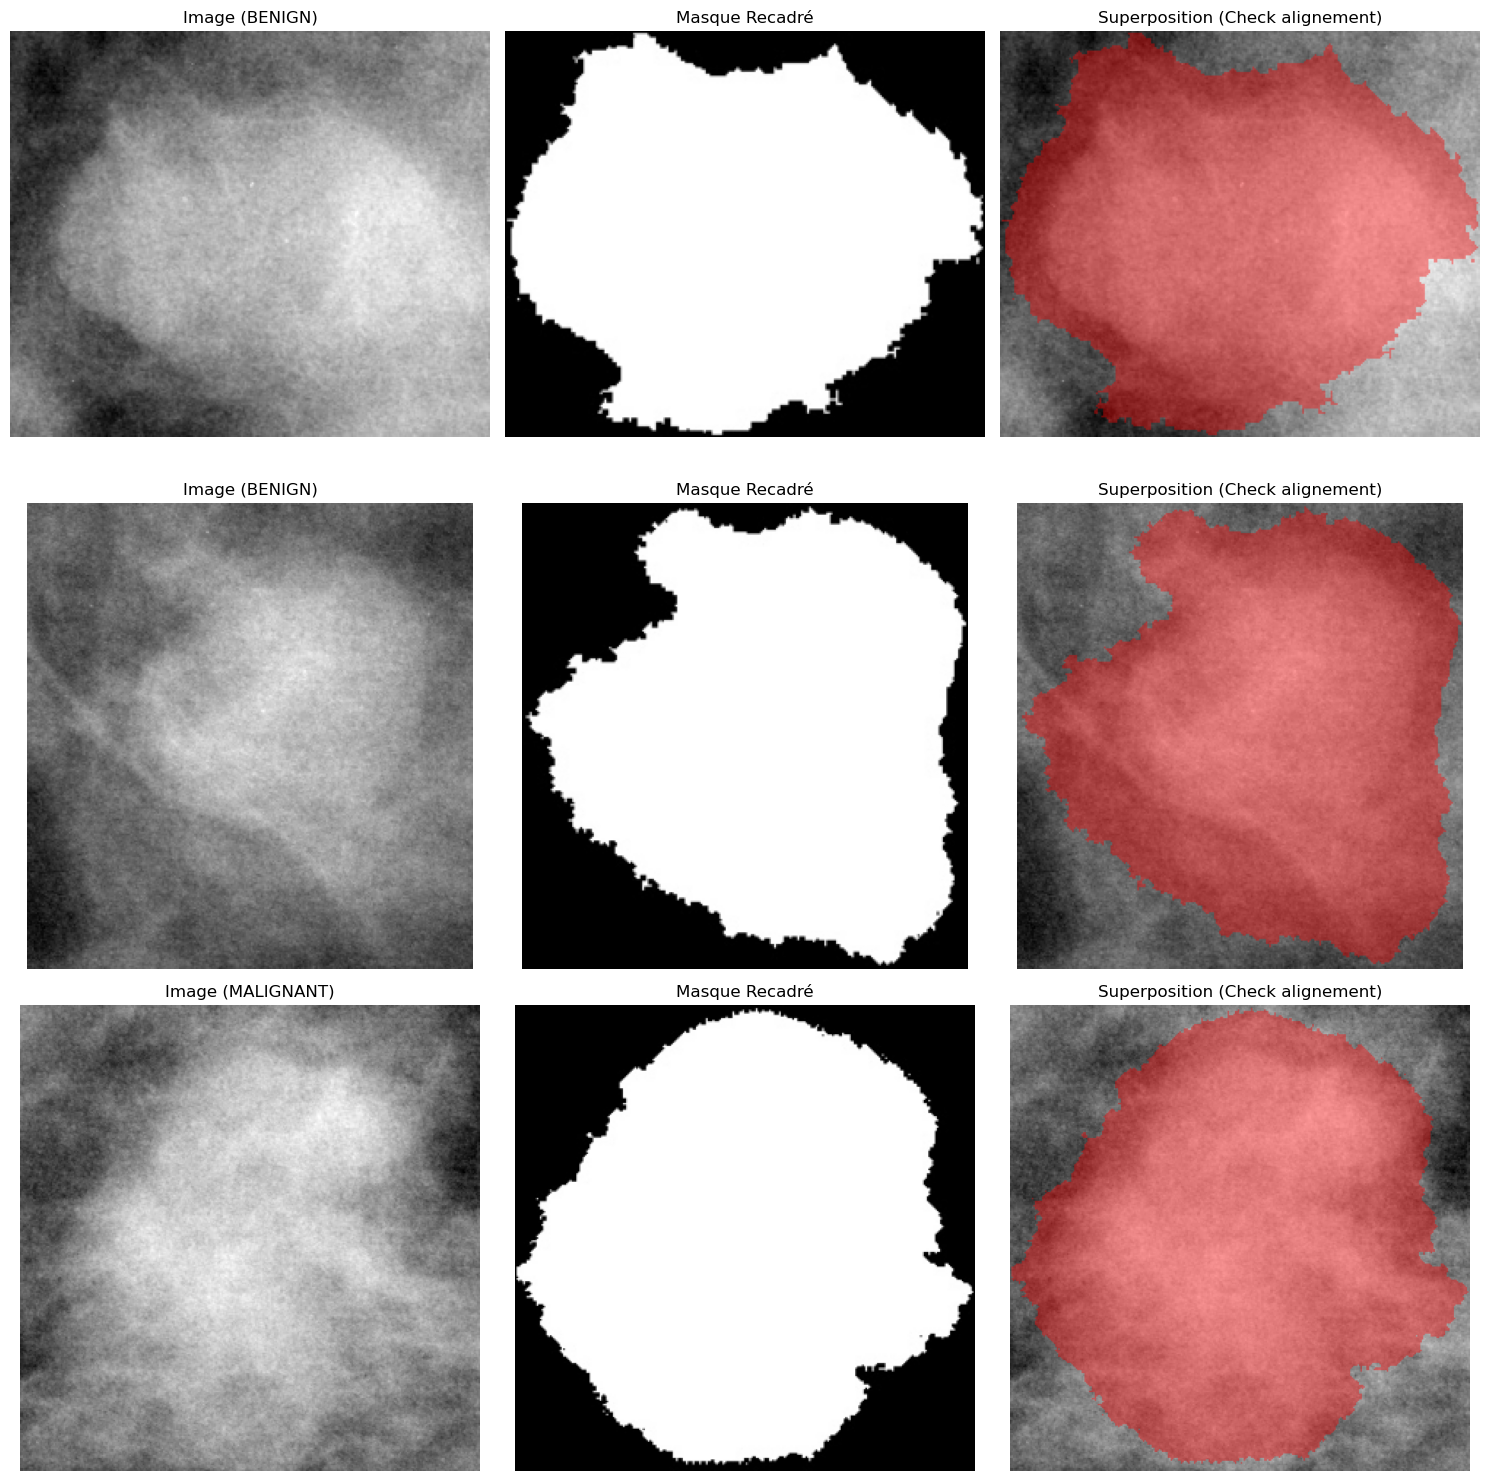

In [ ]:
def verifier_images_et_masques(csv_path="/home/bigbro/master_dataset.csv", num_samples=3):
    print("Chargement du dataset...")
    df = pd.read_csv(csv_path, keep_default_na=False)
    
    df_valid = df[df['mask_status'] != 'n/a'].reset_index(drop=True)
    
    if len(df_valid) == 0:
        print(" Aucun masque valide trouvé dans le CSV !")
        return
        
    print(f" {len(df_valid)} cas avec masques trouvés. Tirage de {num_samples} exemples au hasard...")
    
    samples = df_valid.sample(min(num_samples, len(df_valid)))
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = [axes] 
        
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = row['cropped_image_path']
        mask_path = row['roi_mask_path']
        
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
            print(f" Erreur lecture image : {img_path}")
            
        full_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if full_mask is not None:
            x_min = max(0, int(float(row['x_min'])))
            y_min = max(0, int(float(row['y_min'])))
            x_max = min(full_mask.shape[1], x_min + int(float(row['width'])))
            y_max = min(full_mask.shape[0], y_min + int(float(row['height'])))
            
            mask_crop = full_mask[y_min:y_max, x_min:x_max]
            
            if mask_crop.size > 0 and img.shape[:2] != (0,0):
                mask_crop = cv2.resize(mask_crop, (img.shape[1], img.shape[0]))
            else:
                mask_crop = np.zeros(img.shape[:2], dtype=np.uint8)
        else:
            mask_crop = np.zeros(img.shape[:2], dtype=np.uint8)
            print(f" Erreur lecture masque : {mask_path}")
            
        ax = axes[i]
        
        ax[0].imshow(img)
        ax[0].set_title(f"Image ({row['pathology']})")
        ax[0].axis('off')
        
        ax[1].imshow(mask_crop, cmap='gray')
        ax[1].set_title(f"Mask")
        ax[1].axis('off')
        
        overlay = img.copy()
        mask_bool = mask_crop > 127
        overlay[mask_bool, 0] = 255  
        overlay[mask_bool, 1] = 0    
        overlay[mask_bool, 2] = 0   
        
        alpha = 0.4
        blended = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
        
        ax[2].imshow(blended)
        ax[2].set_title("Superposition")
        ax[2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Lance la vérification
verifier_images_et_masques()

In [96]:
for layer in model.layers:
    if "block5" in layer.name or "block4" in layer.name:
        layer.trainable = True
    else:
        
        if "block" in layer.name:
            layer.trainable = False
        else:
            layer.trainable = True

In [97]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss=bce_dice_loss,
    metrics=["accuracy", 
             keras.metrics.Precision(name='precision'), 
             keras.metrics.Recall(name='recall'), 
             specificity, 
             dice_coef]
)

In [ ]:
callbacks=[
    keras.callbacks.ModelCheckpoint("DDSM_VGG19_U-NET_FT.keras",
                                    save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_dice_coef", patience=7, restore_best_weights=True, mode="max"),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_dice_coef', 
        mode='max',
        factor=0.5,  
        patience=3,   
        min_lr=1e-6,
        verbose=1)
]
history=model.fit(train_generator, 
                  validation_data=val_generator,
                  epochs=30,
                  callbacks=callbacks)

Epoch 1/30


2026-04-27 10:50:22.489520: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


162/162 ━━━━━━━━━━━━━━━━━━━━ 60s 314ms/step - accuracy: 0.8502 - dice_coef: 0.8502 - loss: 0.4888 - precision: 0.8646 - recall: 0.9061 - specificity: 0.7572 - val_accuracy: 0.8380 - val_dice_coef: 0.8401 - val_loss: 0.5288 - val_precision: 0.8500 - val_recall: 0.9146 - val_specificity: 0.6906 - learning_rate: 1.0000e-06
Epoch 2/30
162/162 ━━━━━━━━━━━━━━━━━━━━ 43s 261ms/step - accuracy: 0.8513 - dice_coef: 0.8496 - loss: 0.4872 - precision: 0.8656 - recall: 0.9068 - specificity: 0.7590 - val_accuracy: 0.8378 - val_dice_coef: 0.8408 - val_loss: 0.5292 - val_precision: 0.8469 - val_recall: 0.9192 - val_specificity: 0.6809 - learning_rate: 1.0000e-06
Epoch 3/30
162/162 ━━━━━━━━━━━━━━━━━━━━ 43s 264ms/step - accuracy: 0.8515 - dice_coef: 0.8509 - loss: 0.4845 - precision: 0.8631 - recall: 0.9110 - specificity: 0.7509 - val_accuracy: 0.8398 - val_dice_coef: 0.8392 - val_loss: 0.5230 - val_precision: 0.8566 - val_recall: 0.9080 - val_specificity: 0.7081 - learning_rate: 1.0000e-06
Epoch 4/30
1

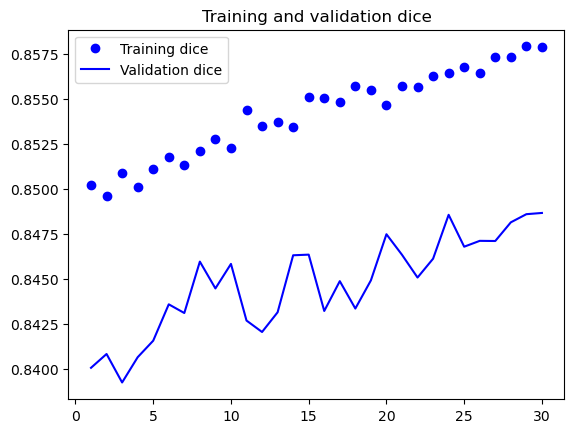

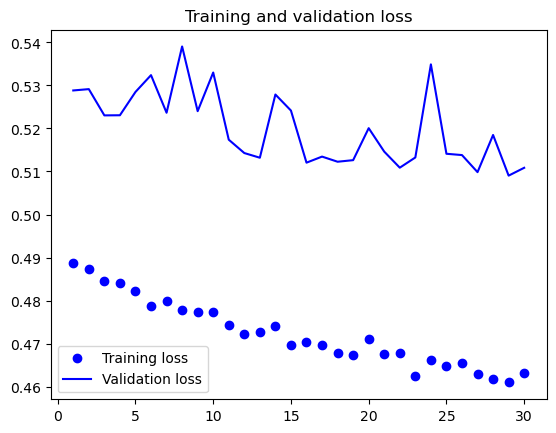

In [99]:
dice = history.history["dice_coef"]
val_dice = history.history["val_dice_coef"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(dice) + 1)
plt.plot(epochs, dice, "bo", label="Training dice")
plt.plot(epochs, val_dice, "b", label="Validation dice")
plt.title("Training and validation dice")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


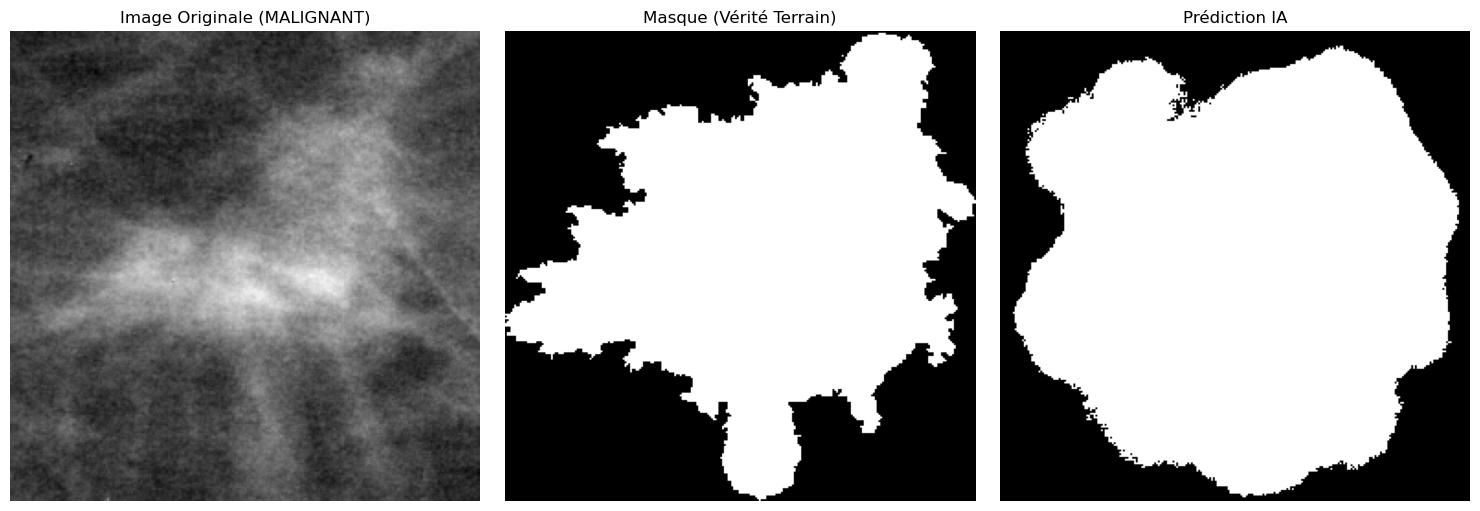

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

idx = 4
IMAGE_SIZE = 256 

img_path_to_test = val_df['cropped_image_path'].iloc[idx]
msk_path_to_test = val_df['roi_mask_path'].iloc[idx]

raw_img = cv2.imread(img_path_to_test)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (IMAGE_SIZE, IMAGE_SIZE))

raw_msk = cv2.imread(msk_path_to_test, cv2.IMREAD_GRAYSCALE)

x_min, y_min = int(float(val_df['x_min'].iloc[idx])), int(float(val_df['y_min'].iloc[idx]))
w, h = int(float(val_df['width'].iloc[idx])), int(float(val_df['height'].iloc[idx]))
raw_msk = raw_msk[y_min:y_min+h, x_min:x_min+w]

raw_msk_resized = cv2.resize(raw_msk, (IMAGE_SIZE, IMAGE_SIZE))
_, raw_msk_resized = cv2.threshold(raw_msk_resized, 127, 255, cv2.THRESH_BINARY)

transformed = val_transforms(image=raw_img)
img_for_model = transformed["image"]

preds = model.predict(np.expand_dims(img_for_model, 0))

if isinstance(preds, list):
    pred_final = preds[1][0] 
else:
    pred_final = preds[0]

pred_mask = (pred_final > 0.5).astype("uint8")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(raw_img)
plt.title(f"Original Image ({val_df['pathology'].iloc[idx]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(raw_msk_resized, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_mask.squeeze() * 255, cmap="gray")
plt.title("Prediction (AI)")
plt.axis("off")

plt.tight_layout()
plt.show()